In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.


two-level system
- degenerate energy levels |0> and |1>
- strong coupling between the levels $J = 0.1$
- long relaxation time scale $\Gamma=10^{-6}$
- no population transitions

In [3]:
J = sp.Symbol("J", real=True)
gamma = sp.Symbol("Gamma", real=True)

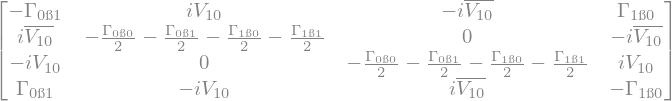

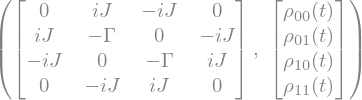

In [4]:
def create_L(output=False):
    # generate general lindbladian
    L, rho = lindbladian(2, output=False, degenerate=True)
    if output: display(L)
    
    # substitute given values
    L = L.subs(sp.Symbol("V10"), J) # coupling

    L = L.subs(sp.Symbol("Gamma_0→0", real=True, nonnegative=True), gamma) # jump
    L = L.subs(sp.Symbol("Gamma_1→1", real=True, nonnegative=True), gamma) # jump

    # no population transitions
    L = L.subs({sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True):0 if i!=j else sp.Symbol(f"Gamma_{i}→{j}", real=True, nonnegative=True) for i in range(2) for j in range(2)})

    return L, rho

create_L(1)

In [4]:
L, rho = create_L()

# solving system analytically
sols_ana = solve_lindblad_ana(L, rho)

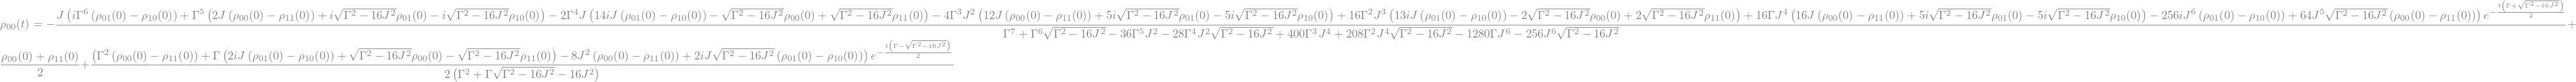

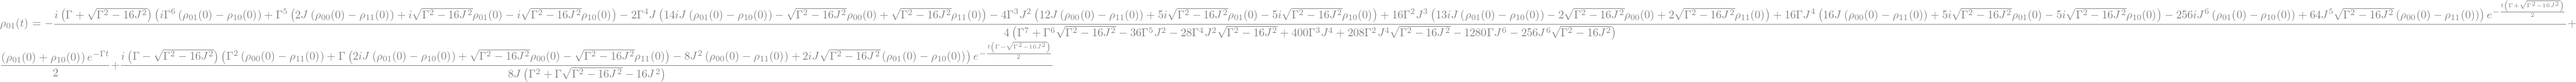

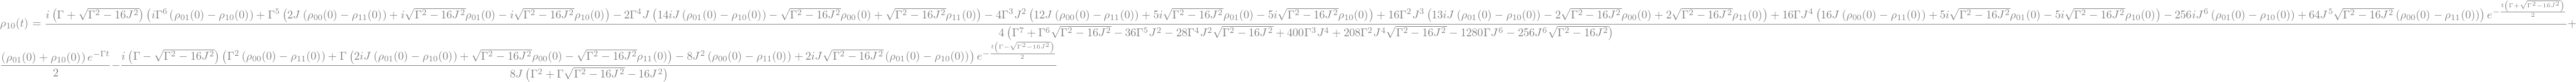

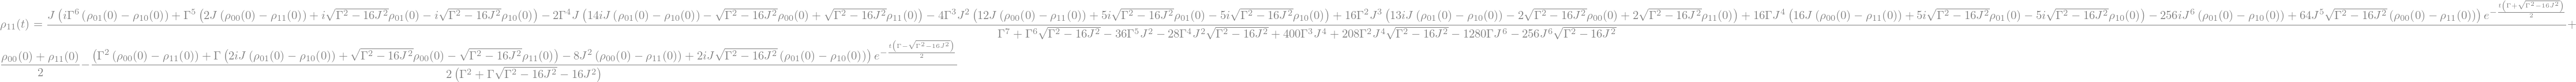

In [5]:
display(sols_ana[0])
display(sols_ana[1])
display(sols_ana[2])
display(sols_ana[3])

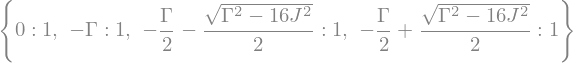

In [6]:
L, rho = create_L()

# finding eigenvalues
L.eigenvals()

Plotting solutions... (using vals from NV paper) with population initally in |0>

/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'prob')

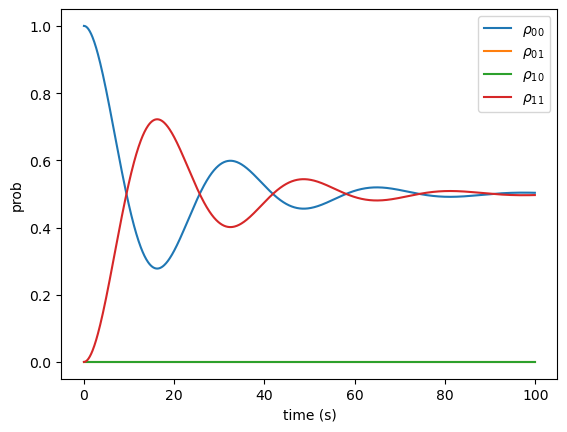

In [7]:
# analytically

L, rho = create_L()
L = L.subs({J:0.1, gamma:1e-1})
sols = solve_lindblad_ana(L, rho, [1,0,0,0])

plt.plot(*compute_eq_ana(sols[0].rhs, "t", 0, 100, 0.1), label=r"$\rho_{00}$")
plt.plot(*compute_eq_ana(sols[1].rhs, "t", 0, 100, 0.1), label=r"$\rho_{01}$")
plt.plot(*compute_eq_ana(sols[2].rhs, "t", 0, 100, 0.1), label=r"$\rho_{10}$")
plt.plot(*compute_eq_ana(sols[3].rhs, "t", 0, 100, 0.1), label=r"$\rho_{11}$")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("prob")

Text(0, 0.5, 'prob')

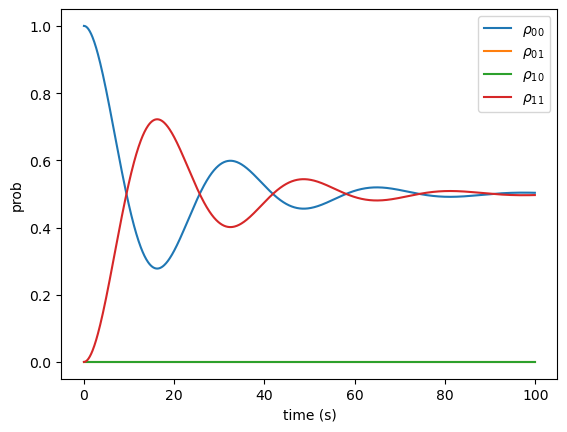

In [8]:
# numerically

L, rho = create_L()
L = L.subs({J:0.1, gamma:0.1})
times, sols_num = solve_lindblad_num(L, 0, 100, 0.1, [1, 0,0,0])


plt.plot(times, sols_num[0], label=r"$\rho_{00}$")
plt.plot(times, sols_num[1], label=r"$\rho_{01}$")
plt.plot(times, sols_num[2], label=r"$\rho_{10}$")
plt.plot(times, sols_num[3], label=r"$\rho_{11}$")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("prob")

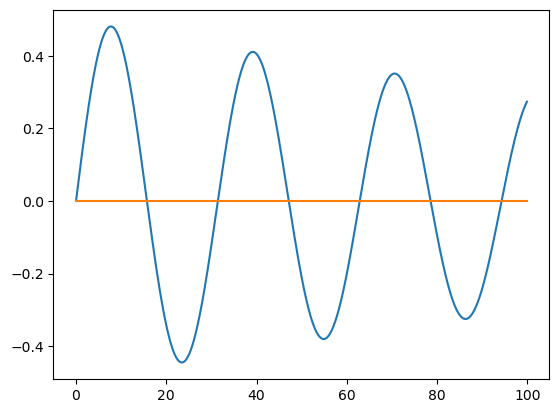

In [20]:
plt.plot(times, np.imag(sols_num[1]), label=r"$\rho_{01}$")
plt.plot(times, np.real(sols_num[1]), label=r"$\rho_{01}$")